# DATA PREPAREATION

In [73]:
import torch
import os
from dataset.climatenet import ClimateDataset 
from torch.utils.data import DataLoader
import random
import numpy as np
from functools import partial

def setup_device_and_distributed(worker_id):
    gpu_num = 1
    world_size = os.environ['WORLD_SIZE'] if 'WORLD_SIZE' in os.environ.keys() else gpu_num
    base_rank = os.environ['RANK'] if 'RANK' in os.environ.keys() else 0
    local_rank = (base_rank * gpu_num) + worker_id

    device = torch.device(f"cuda:{worker_id}")
    torch.cuda.set_device(device)
    return device, local_rank

device, local_rank = setup_device_and_distributed(0)

def worker_init_fn(worker_id: int, base_seed: int, same_worker_seed: bool = True):
    """
    Set random seed for each worker in DataLoader to ensure the reproducibility.

    """
    seed = base_seed if same_worker_seed else base_seed + worker_id

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

In [74]:

data_dir = "../data/"
train_dataset = ClimateDataset(
        data_dir=data_dir, train_flag=True, generate_prompt=True, augmented=True
    )
val_dataset = ClimateDataset(
        data_dir=data_dir, train_flag=False, generate_prompt=True, augmented=False
    )

train_dataloader = DataLoader(
        dataset=train_dataset, batch_size=4, shuffle=False is None, num_workers=0,
        sampler=None, drop_last=False, collate_fn=train_dataset.collate_fn,
        worker_init_fn=partial(worker_init_fn, base_seed=3407)
    )
val_dataloader = DataLoader(
    dataset=val_dataset, batch_size=4, shuffle=False, num_workers=0,
    drop_last=False, collate_fn=val_dataset.collate_fn, worker_init_fn=partial(worker_init_fn, base_seed=3407)
)
    
    


In [75]:
# Get one gt
# Get ar_gt and tc_gt
# Get connected components
# get bbox and points and mask


In [76]:
from utility import plot_mask_with_points_and_bbox
from utility import batch_to_cuda
for val_step, batch in enumerate(val_dataloader):
    batch = batch_to_cuda(batch, device)
    break

In [77]:
i = 0
gt_mask = batch['gt_mask'][0]
tc_gt_mask = (batch['gt_mask'][0] == 1).to(torch.uint8).cpu().numpy()
ar_gt_mask = (batch['gt_mask'][0] == 2).to(torch.uint8).cpu().numpy()

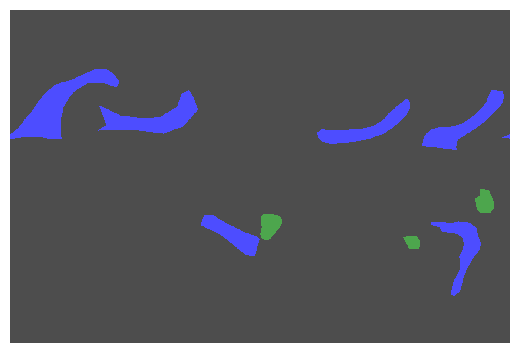

In [134]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt

mask = gt_mask.cpu().numpy().astype(int)

cmap = ListedColormap(['black', 'green', 'blue'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(mask, cmap=cmap, norm=norm, interpolation='nearest', alpha=0.7)
ax.set_axis_off()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.margins(0)
ax.set_position([0, 0, 1, 1])
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

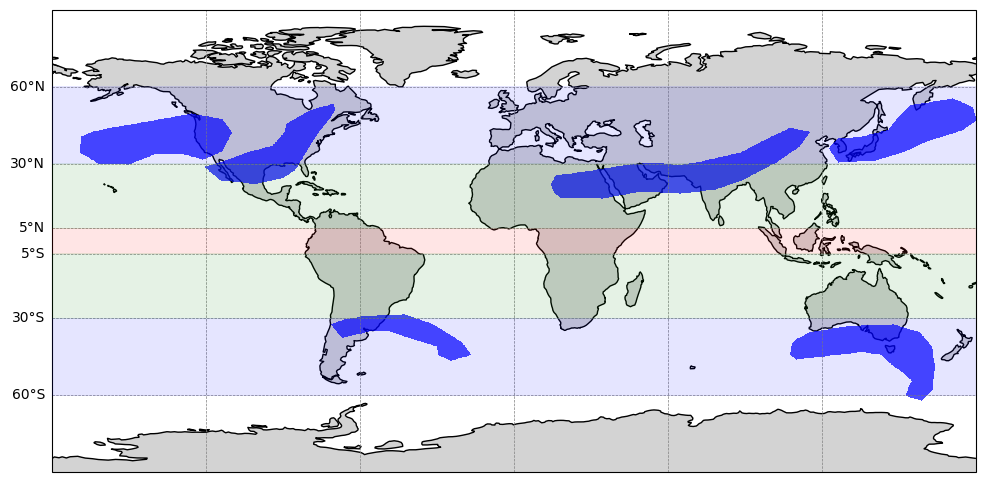

In [146]:
# Plot ground-truth mask on a global PlateCarree projection (no legend).
# Shows latitude lines at 5, 30, 60 degrees (and their negatives) with labels.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import matplotlib.ticker as mticker
    has_cartopy = True
except Exception:
    has_cartopy = False

# Prepare mask arrays
gt_mask = batch['gt_mask'][3]
mask = gt_mask.cpu().numpy().astype(int)
# AR (value 2) and TC (value 1)
ar_gt = (mask == 2).astype(float)
tc_gt = (mask == 1).astype(float)

# Longitude / latitude axes assuming full-world extent
# Ensure lat is ascending (from -90 at bottom to 90 at top)
lon = np.linspace(-180, 180, mask.shape[1])
lat = np.linspace(90, -90, mask.shape[0])
Lon, Lat = np.meshgrid(lon, lat)

# Define latitudinal band masks (absolute latitudes)
band_eq = (np.abs(Lat) <= 5)
band_mid = ((np.abs(Lat) > 5) & (np.abs(Lat) <= 30))
band_high = ((np.abs(Lat) > 30) & (np.abs(Lat) <= 60))

# Desired tick latitudes; ensure sorted ascending
lat_ticks = sorted([-60, -30, -5, 5, 30, 60])
lon_ticks = [-180, -120, -60, 0, 60, 120, 180]

if has_cartopy:
    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()

    # Background image: light land
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.COASTLINE, edgecolor='black', zorder=1)

    # Contour-fill ground truth masks (no legend)
    ax.contourf(lon, lat, ar_gt, levels=[0.5, 1.0], colors=['blue'], alpha=0.7, transform=ccrs.PlateCarree(), zorder=2)
    ax.contourf(lon, lat, tc_gt, levels=[0.5, 1.0], colors=['green'], alpha=0.7, transform=ccrs.PlateCarree(), zorder=3)

    # Overlay latitudinal bands with very low opacity (5% = 0.05)
    ax.contourf(lon, lat, band_eq.astype(float), levels=[0.5, 1.0], colors=['red'], alpha=0.1, transform=ccrs.PlateCarree(), zorder=4)
    ax.contourf(lon, lat, band_mid.astype(float), levels=[0.5, 1.0], colors=['green'], alpha=0.1, transform=ccrs.PlateCarree(), zorder=5)
    ax.contourf(lon, lat, band_high.astype(float), levels=[0.5, 1.0], colors=['blue'], alpha=0.1, transform=ccrs.PlateCarree(), zorder=6)

    # Gridlines and labeled latitudes
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
    # show labels only on left for y
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False
    gl.left_labels = True

    # Set tick locators using sorted ascending latitudes
    gl.xlocator = mticker.FixedLocator(lon_ticks)
    gl.ylocator = mticker.FixedLocator(lat_ticks)
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

    # Remove any extra axes decorations where possible
    try:
        ax.outline_patch.set_visible(False)
    except Exception:
        pass

    # plt.title('Ground truth (global projection)')
    plt.show()
else:
    # Fallback: simple imshow with no projection
    cmap = ListedColormap(['black', 'green', 'blue'])
    fig, ax = plt.subplots(figsize=(10, 5))
    # Flip mask vertically so that latitude ordering is bottom->top when using origin='lower'
    display_mask = np.flipud(mask)
    ax.imshow(display_mask, cmap=cmap, interpolation='nearest', origin='lower', extent=[-180, 180, -90, 90])
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)

    # Overlay latitudinal bands using axhspan (5% opacity)
    ax.axhspan(-5, 5, color='red', alpha=0.05, zorder=2)
    ax.axhspan(5, 30, color='yellow', alpha=0.05, zorder=2)
    ax.axhspan(-30, -5, color='yellow', alpha=0.05, zorder=2)
    ax.axhspan(30, 60, color='purple', alpha=0.05, zorder=2)
    ax.axhspan(-60, -30, color='purple', alpha=0.05, zorder=2)

    # Show horizontal lines at requested latitudes and label them
    for lt in lat_ticks:
        ax.axhline(lt, color='white', linestyle='--', linewidth=0.6)
        ax.text(-175, lt + 1.5, f'{lt}°', color='white', fontsize=9, va='center')

    ax.axis('off')
    plt.title('Ground truth (fallback, no projection)')
    plt.show()


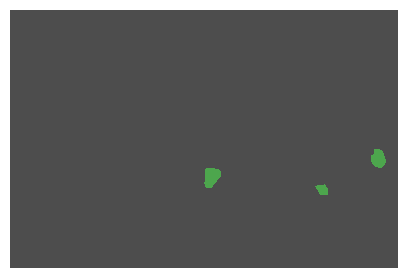

In [79]:
plt.figure(figsize=(5, 4))
plt.imshow(tc_gt_mask, cmap=ListedColormap(['black', 'green']), norm=norm, interpolation='nearest', alpha= 0.7)
plt.axis('off')
plt.show()

In [80]:
ar_object_masks = batch['ar_object_masks'][0]

ar_object_masks.shape

torch.Size([7, 1, 768, 1152])

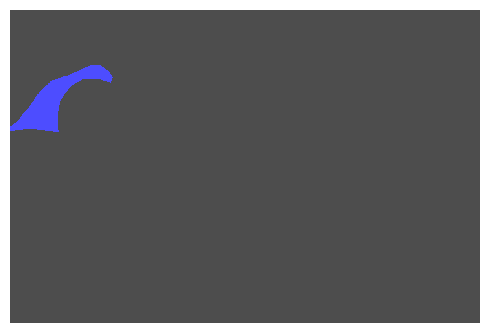

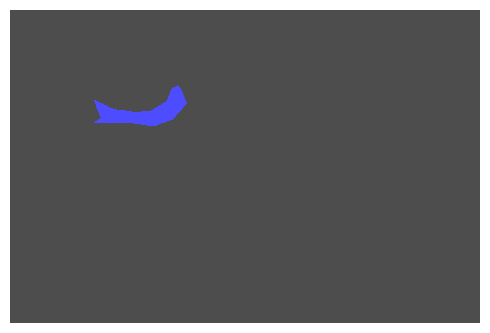

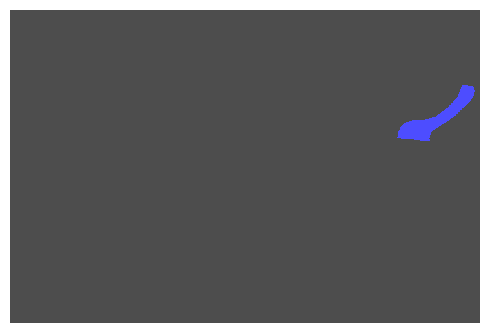

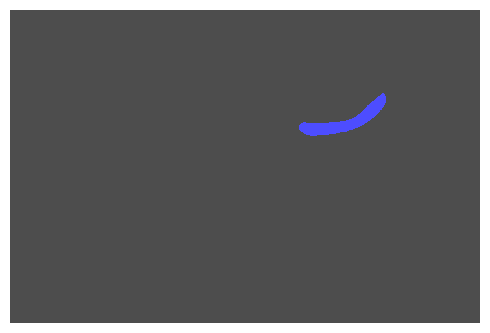

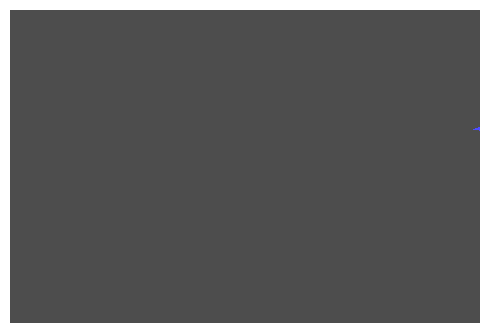

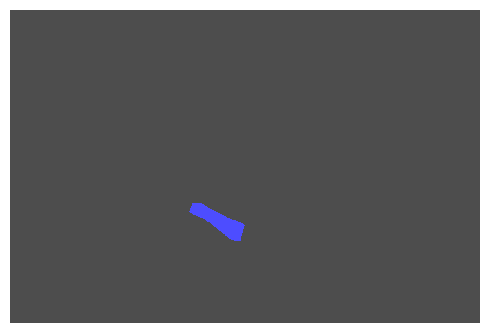

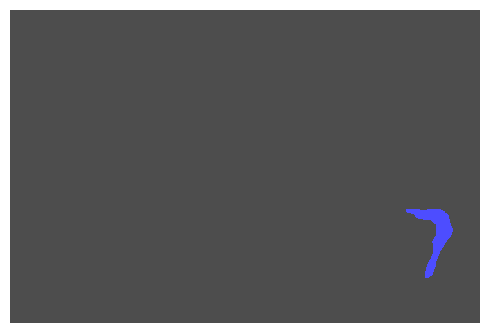

In [126]:
# plot each ar object mask in its own figure (one after another)
try:
    masks = ar_object_masks.cpu().numpy()
except Exception:
    masks = np.array(ar_object_masks)

# collapse channel dim if present: expected (N, 1, H, W) -> (N, H, W)
if masks.ndim == 4 and masks.shape[1] == 1:
    masks = masks[:, 0, ...]
elif masks.ndim == 4 and masks.shape[1] != 1:
    masks = masks.max(axis=1)
elif masks.ndim == 2:
    masks = masks[None, ...]

cmap_ar = ListedColormap(['black', 'blue'])

for i, m in enumerate(masks):
    m2 = (np.squeeze(m) > 0.5).astype(np.uint8)
    plt.figure(figsize=(5, 4))
    plt.imshow(m2, cmap=cmap_ar, interpolation='nearest', alpha=0.7)
    # plt.title(f"mask {i}", fontsize=10)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


In [82]:
# create one point prompt, one bbox prompt, and one mask prompt for batch['ar_object_masks'][0][0]

obj = batch['ar_object_masks'][0][0]  # tensor, may be (1,H,W) or (H,W) or (1,1,H,W)
m = obj.cpu().numpy()

# normalize possible channel dims -> (H, W)
if m.ndim == 4 and m.shape[1] == 1:
    m = m[0, 0, ...]
elif m.ndim == 3 and m.shape[0] == 1:
    m = m[0, ...]
elif m.ndim == 3 and m.shape[0] != 1:
    m = m.max(axis=0)

bin_mask = (m > 0.5).astype(np.uint8)
h, w = bin_mask.shape

ys, xs = np.where(bin_mask)
if ys.size == 0:
    # fallback to image center and full-image bbox when object is empty
    cx, cy = w // 2, h // 2
    x1, y1, x2, y2 = 0, 0, w - 1, h - 1
else:
    y1, y2 = int(ys.min()), int(ys.max())
    x1, x2 = int(xs.min()), int(xs.max())
    cy = int(round((y1 + y2) / 2.0))
    cx = int(round((x1 + x2) / 2.0))

# point prompt as (x, y)
ar_point_prompt = torch.tensor([[float(cx), float(cy)]], dtype=torch.float32, device=device)

# bbox prompt as [x1, y1, x2, y2] with same nesting as existing prompts
ar_bbox_prompt = torch.tensor([[[float(x1), float(y1), float(x2), float(y2)]]], dtype=torch.float32, device=device)

# mask prompt as binary mask tensor on the same device
ar_mask_prompt = torch.from_numpy(bin_mask).to(device)  # shape (H, W)

print("ar_point_prompt:", ar_point_prompt)
print("ar_bbox_prompt:", ar_bbox_prompt)
print("ar_mask_prompt.shape:", ar_mask_prompt.shape)

ar_point_prompt: tensor([[126., 218.]], device='cuda:0')
ar_bbox_prompt: tensor([[[  0., 136., 251., 300.]]], device='cuda:0')
ar_mask_prompt.shape: torch.Size([768, 1152])


Visualize the selected AR object mask in four variants (no legend / no grid):

1) Raw object mask
2) Mask with bounding box
3) Mask with point prompt
4) Noisy mask (uses make_noisy_mask_on_objects when available, otherwise a fallback)

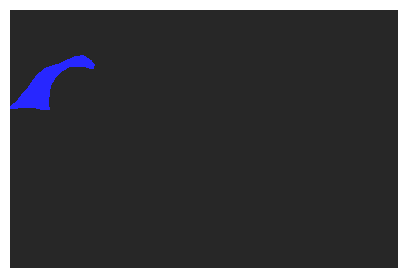

In [84]:

# 1) Raw object mask (no legend, no grid)
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import torch

# Derive a 2D binary mask from ar_mask_prompt (preferred) or fallback to obj
try:
    mask_np = ar_mask_prompt.detach().cpu().numpy()
except Exception:
    tmp = obj.detach().cpu().numpy() if isinstance(obj, torch.Tensor) else np.array(obj)
    if tmp.ndim == 4 and tmp.shape[1] == 1:
        tmp = tmp[0, 0, ...]
    elif tmp.ndim == 3 and tmp.shape[0] == 1:
        tmp = tmp[0, ...]
    elif tmp.ndim == 3 and tmp.shape[0] != 1:
        tmp = tmp.max(axis=0)
    mask_np = (tmp > 0.5).astype(np.uint8)

cmap_ar = ListedColormap(['black', 'blue'])
plt.figure(figsize=(5, 4))
plt.imshow(mask_np, cmap=cmap_ar, interpolation='nearest', alpha=0.85)
plt.axis('off')
plt.show()

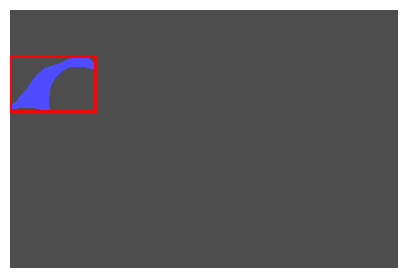

In [90]:
# 2) Mask with bounding box (no legend, no grid)
import matplotlib.patches as patches
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(mask_np, cmap=cmap_ar, interpolation='nearest', alpha=0.7)

# Try to extract bbox from ar_bbox_prompt
try:
    bbox_arr = ar_bbox_prompt.detach().cpu().numpy().reshape(-1, 4)
    x1, y1, x2, y2 = map(float, bbox_arr[0])
    width = x2 - x1
    height = y2 - y1
    rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='red', facecolor='none', )
    ax.add_patch(rect)
except Exception:
    # no bbox available; nothing to add
    pass

ax.axis('off')
plt.show()

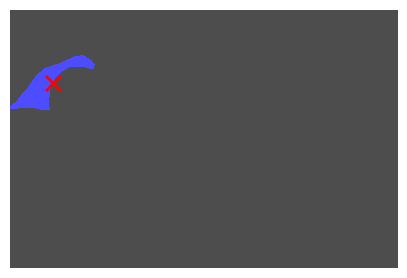

In [92]:
#  3) Mask with point prompt (no legend, no grid)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(mask_np, cmap=cmap_ar, interpolation='nearest', alpha=0.7)

# Try to extract the point from ar_point_prompt
try:
    pts = ar_point_prompt.detach().cpu().numpy().reshape(-1, 2)
    px, py = pts[0]
    # plot as red 'x'
    ax.scatter(px, py, marker='x', color='red', s=120, linewidths=2)
except Exception:
    pass

ax.axis('off')
plt.show()

In [121]:
import torch
import torch.nn.functional as F

def make_noisy_mask_on_objects(object_masks, scale_factor: int = 8, noisy_mask_threshold: float = 0.5, h = 256, w = 256):
    """
        Add noise to mask input
        From Mask Transfiner https://github.com/SysCV/transfiner
    """
    def get_incoherent_mask(input_masks, h, w):
        mask = input_masks.float()
        h, w = input_masks.shape[-2:]

        mask_small = F.interpolate(mask, (h // scale_factor, w // scale_factor), mode='bilinear')
        mask_recover = F.interpolate(mask_small, (h, w), mode='bilinear')
        mask_residue = (mask - mask_recover).abs()
        mask_residue = (mask_residue >= 0.01).float()
        return mask_residue
    
    if object_masks.dim() == 3:
        object_masks = object_masks.unsqueeze(1)

    o_m_resized = F.interpolate(object_masks.float(), (h, w), mode='bilinear')
    mask_noise = torch.randn(o_m_resized.shape) * 1.0
    inc_masks = get_incoherent_mask(o_m_resized, h, w)
    o_m_noisy = ((o_m_resized + mask_noise * inc_masks) > noisy_mask_threshold).float()
    
    return o_m_noisy

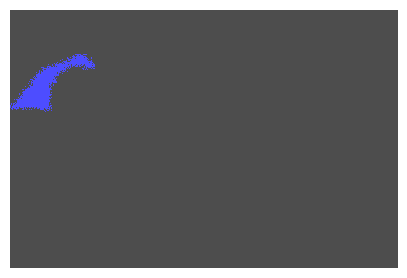

In [124]:
# noisy mask visualization (use make_noisy_mask_on_objects if available)
from matplotlib.colors import ListedColormap
import torch
import numpy as np
import torch.nn.functional as F

# Prepare object tensor with shape (N,1,H,W)
obj_t = obj
if isinstance(obj_t, np.ndarray):
    obj_t = torch.from_numpy(obj_t)
obj_t = obj_t.float()
if obj_t.dim() == 2:
    obj_t = obj_t.unsqueeze(0).unsqueeze(0)
elif obj_t.dim() == 3:
    # if (1,H,W) -> add batch dim; if (N,H,W) -> add channel dim
    if obj_t.shape[0] == 1:
        obj_t = obj_t.unsqueeze(0)
    else:
        obj_t = obj_t.unsqueeze(1)
elif obj_t.dim() == 4 and obj_t.shape[1] != 1:
    obj_t = obj_t.max(dim=1, keepdim=True)[0]

# Ensure mask_np is defined
if 'mask_np' not in globals():
    try:
        mask_np = ar_mask_prompt.detach().cpu().numpy()
    except Exception:
        tmp = obj.detach().cpu().numpy() if isinstance(obj, torch.Tensor) else np.array(obj)
        if tmp.ndim == 4 and tmp.shape[1] == 1:
            tmp = tmp[0, 0, ...]
        elif tmp.ndim == 3 and tmp.shape[0] == 1:
            tmp = tmp[0, ...]
        elif tmp.ndim == 3 and tmp.shape[0] != 1:
            tmp = tmp.max(axis=0)
        mask_np = (tmp > 0.5).astype(np.uint8)

# Attempt to use the utility function; run on CPU to avoid device mismatch inside function
try:
    from dataset.climatenet_util import make_noisy_mask_on_objects
    noisy = make_noisy_mask_on_objects(obj_t.cpu(), h=mask_np.shape[0], w=mask_np.shape[1])
    noisy_np = noisy.squeeze().cpu().numpy()
except Exception as e:
    # fallback: resize and add gaussian noise (operate on CPU)
    try:
        o = F.interpolate(obj_t.cpu(), size=mask_np.shape, mode='bilinear')
        noise = torch.randn_like(o) * 0.8
        noisy_tensor = ((o + noise) > 0.5).float()
        noisy_np = noisy_tensor.squeeze().cpu().numpy()
    except Exception as e2:
        print('Failed to compute noisy mask:', e, e2)
        noisy_np = mask_np.copy()

cmap_noisy = ListedColormap(['black', 'blue'])
plt.figure(figsize=(5, 4))
plt.imshow(noisy_np, cmap=cmap_noisy, interpolation='nearest', alpha=0.7)
plt.axis('off')
plt.show()


In [106]:
obj_t.squeeze().shape

torch.Size([768, 1152])

Scanning train: 100%|██████████| 398/398 [00:25<00:00, 15.66it/s]
Scanning train: 100%|██████████| 398/398 [00:25<00:00, 15.66it/s]
Scanning test: 100%|██████████| 61/61 [00:04<00:00, 14.52it/s]
--- Train ---
Number of samples: 398
Average TC objects per sample: 2.570 (median 2.0)
Average AR objects per sample: 7.706 (median 8.0)
Samples with no TC labels: 67 / 398
Class pixel counts:
  class 0: 330520699 (freq 0.938646)
  class 1: 1626347 (freq 0.004619)
  class 2: 19977882 (freq 0.056735)
Mean TC pixels per image: 4086.3 (median 3425.0)
Mean AR pixels per image: 50195.7 (median 49199.0)


--- Val ---
Number of samples: 61
Average TC objects per sample: 2.934 (median 2.0)
Average AR objects per sample: 6.967 (median 7.0)
Samples with no TC labels: 14 / 61
Class pixel counts:
  class 0: 50654302 (freq 0.938583)
  class 1: 296594 (freq 0.005496)
  class 2: 3018000 (freq 0.055921)
Mean TC pixels per image: 4862.2 (median 3006.0)
Mean AR pixels per image: 49475.4 (median 47352.0)

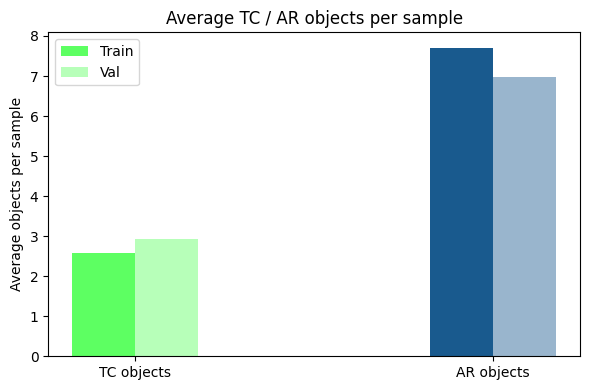

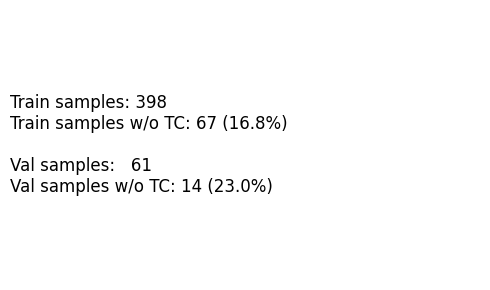

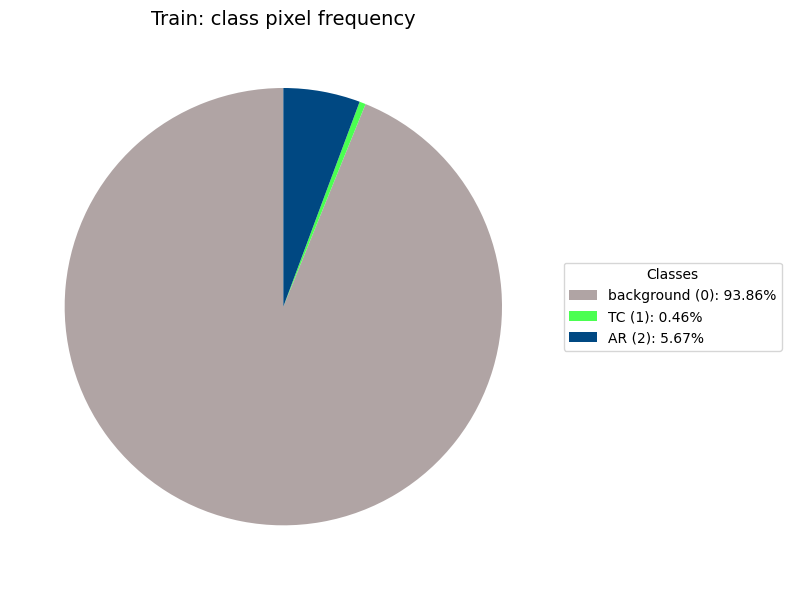

<Figure size 640x480 with 0 Axes>

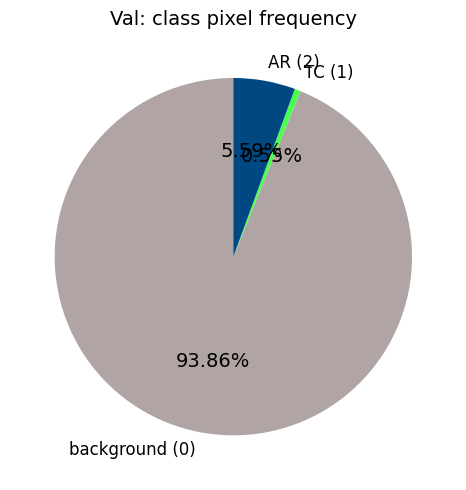

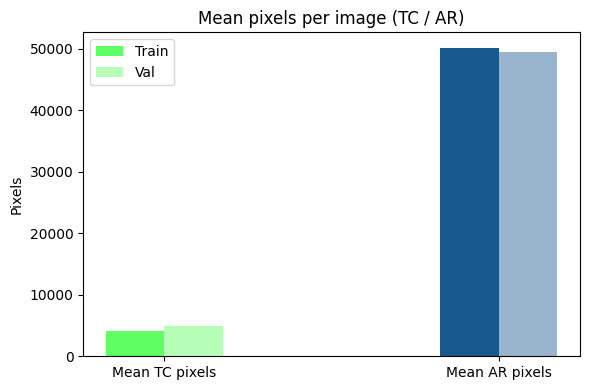

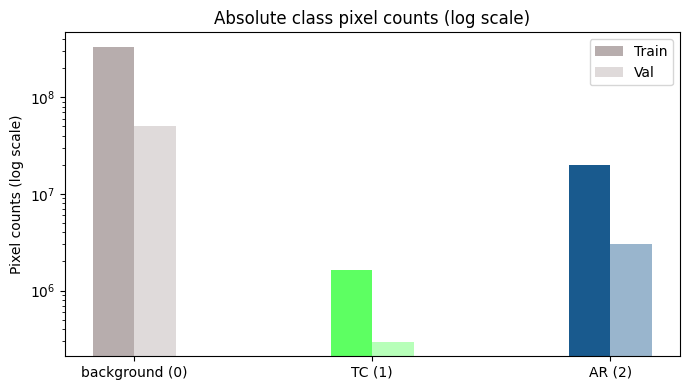

In [195]:
import numpy as np
import matplotlib.pyplot as plt

# enforce requested colors: gray background, green TC, blue AR
colors_classes = ["#b0a4a4", "#4bff51", "#004882"]  # background, TC, AR
tc_color = colors_classes[1]
ar_color = colors_classes[2]
bg_color = colors_classes[0]

# 1) Average object counts (TC / AR) - separate figure
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
labels = ['TC objects', 'AR objects']
train_vals = [train['avg_tc'], train['avg_ar']]
val_vals = [val['avg_tc'], val['avg_ar']]
x = np.arange(len(labels))
width = 0.35
off = width / 4
ax.bar(x - off, train_vals, width/2, label='Train', color=[tc_color, ar_color], alpha=0.9)
ax.bar(x + off, val_vals, width/2, label='Val', color=[tc_color, ar_color], alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Average objects per sample')
ax.set_title('Average TC / AR objects per sample')
ax.legend()
plt.tight_layout()
plt.show()

# 2) Samples counts and no-TC summary (text) - separate figure
fig = plt.figure(figsize=(5, 3))
ax = fig.add_subplot(1, 1, 1)
ax.axis('off')
txt = (
    f"Train samples: {train['num_samples']}\n"
    f"Train samples w/o TC: {train['no_tc_samples']} ({train['no_tc_samples']/train['num_samples']:.1%})\n\n"
    f"Val samples:   {val['num_samples']}\n"
    f"Val samples w/o TC: {val['no_tc_samples']} ({val['no_tc_samples']/val['num_samples']:.1%})"
)
ax.text(0, 0.5, txt, fontsize=12, va='center')
plt.tight_layout()
plt.show()

# 3) Class pixel frequency pie chart (Train) - Updated


# 3) Class pixel frequency pie chart (Train) - Legend Style
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate total for percentages or use raw freqs
total = sum(train['class_freqs'])
legend_labels = [f'{c}: {v/total*100:.2f}%' for c, v in zip(classes, train['class_freqs'])]

wedges, texts = ax.pie(
    train['class_freqs'],
    colors=colors_classes,
    startangle=90,
    textprops={'fontsize': 12}
)

# Add the legend with the formatted labels
ax.legend(
    wedges, 
    legend_labels,
    title="Classes",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=10
)

ax.set_title('Train: class pixel frequency', fontsize=14)
plt.tight_layout()
plt.show()
# Style adjustments
for t in texts:
    t.set_fontsize(12)
for t in autotexts:
    t.set_fontsize(12) # Slightly smaller font often looks better when outside
    t.set_color('black') # Ensure they are visible against the background

ax.set_title('Train: class pixel frequency', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# 4) Class pixel frequency pie chart (Val) - separate figure
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1)
wedges, texts, autotexts = ax.pie(
    val['class_freqs'],
    labels=classes,
    autopct='%1.2f%%',
    colors=colors_classes,
    startangle=90
)
for t in texts:
    t.set_fontsize(12)
for t in autotexts:
    t.set_fontsize(14)
ax.set_title('Val: class pixel frequency', fontsize=14)
plt.tight_layout()
plt.show()

# 5) Mean pixels per image (TC and AR) - separate figure
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
labels2 = ['Mean TC pixels', 'Mean AR pixels']
train_pix = [train['mean_tc_pixels'], train['mean_ar_pixels']]
val_pix = [val['mean_tc_pixels'], val['mean_ar_pixels']]
x2 = np.arange(len(labels2))
ax.bar(x2 - off, train_pix, width/2, label='Train', color=[tc_color, ar_color], alpha=0.9)
ax.bar(x2 + off, val_pix, width/2, label='Val', color=[tc_color, ar_color], alpha=0.4)
ax.set_xticks(x2)
ax.set_xticklabels(labels2)
ax.set_ylabel('Pixels')
ax.set_title('Mean pixels per image (TC / AR)')
ax.legend()
plt.tight_layout()
plt.show()

# 6) Absolute class pixel counts (log scale) for train vs val - separate figure
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(1, 1, 1)
x3 = np.arange(len(classes))
train_counts = train['class_counts']
val_counts = val['class_counts']
# use class colors for both train/val, differentiate by alpha
class_colors_list = [bg_color, tc_color, ar_color]
ax.bar(x3 - off, train_counts, width/2, label='Train', color=class_colors_list, alpha=0.9)
ax.bar(x3 + off, val_counts, width/2, label='Val', color=class_colors_list, alpha=0.4)
ax.set_xticks(x3)
ax.set_xticklabels(classes)
ax.set_yscale('log')
ax.set_ylabel('Pixel counts (log scale)')
ax.set_title('Absolute class pixel counts (log scale)')
ax.legend()
plt.tight_layout()
plt.show()


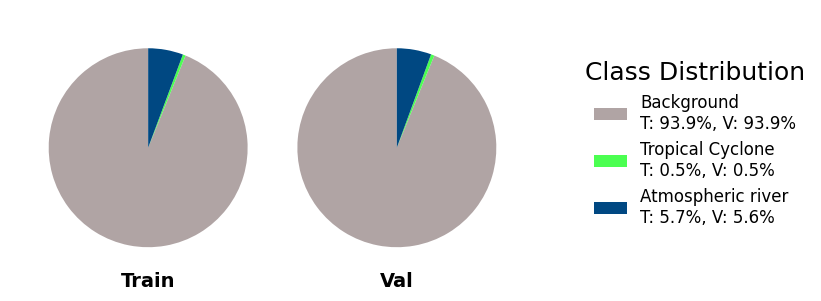

In [208]:
import matplotlib.pyplot as plt
classes = ['Background', 'Tropical Cyclone ', 'Atmospheric river']
# Reduce the figure width from 10 to 7 to force them together
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 4))

# 1. Calculate totals and percentages
total_train = sum(train['class_freqs'])
total_val = sum(val['class_freqs'])

train_pcts = [v/total_train*100 for v in train['class_freqs']]
val_pcts = [v/total_val*100 for v in val['class_freqs']]

# 2. Combined labels
combined_labels = [
    f'{c}\nT: {t:.1f}%, V: {v:.1f}%' 
    for c, t, v in zip(classes, train_pcts, val_pcts)
]

# 3. Train Pie
wedges, _ = ax1.pie(
    train['class_freqs'],
    colors=colors_classes,
    startangle=90,
    radius=0.9 # Slightly larger radius helps them look closer
)
ax1.set_xlabel('Train', fontsize=14, fontweight='bold', labelpad=-10)

# 4. Val Pie
ax2.pie(
    val['class_freqs'],
    colors=colors_classes,
    startangle=90,
    radius=0.9
)
ax2.set_xlabel('Val', fontsize=14, fontweight='bold', labelpad=-10)

# 5. Legend - Moved closer to the charts (anchor 0.8)
fig.legend(
    wedges, 
    combined_labels, 
    title="Class Distribution",
    title_fontsize=18, 
    loc="center left", 
    bbox_to_anchor=(0.8, 0.5), 
    fontsize=12,
    frameon=False
)

# 6. Negative wspace can actually overlap them if you want them "touching"
plt.subplots_adjust(wspace=-0.1, left=0.0, right=0.75, bottom=0.1)

# Save as transparent PNG
plt.savefig('ultra_compact_distribution.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()